In [1]:
import os, sys
project_root = os.path.abspath('..').replace('\\', '/')
if project_root not in [p.replace('\\', '/') for p in sys.path]:
    sys.path.append(project_root)

# 12 完整建模工作流演示

本 Notebook 演示完整的风控建模流程，包括：
1. 数据加载与探索
2. 特征工程
3. 特征筛选
4. 模型训练
5. 模型评估
6. 生成模型报告

**数据说明**: 基于 `hscredit_yyp.xlsx`，目标变量为 `MOB1 > 3`

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

from hscredit import init_setting
from hscredit.core import metrics, viz

init_setting()

# 加载数据
_roots = [Path.cwd(), Path.cwd() / 'examples', Path.cwd().parent]
_fp = None
for _r in _roots:
    for _n in ('hscredit_yyp.xlsx', 'hengshucredit_yyp.xlsx'):
        if (_r / _n).is_file():
            _fp = _r / _n
            break
    if _fp is not None:
        break
if _fp is None:
    raise FileNotFoundError('请将 hscredit_yyp.xlsx 放在 examples/')

df = pd.read_excel(_fp)

# 构造目标变量
df['target'] = (df['MOB1'] > 3).astype(int)

print("=" * 50)
print("数据加载完成")
print("=" * 50)
print(f"样本数: {len(df):,}")
print(f"特征数: {df.shape[1]}")
print(f"放款时间范围: {df['放款时间'].min()} ~ {df['放款时间'].max()}")
print(f"坏样本率: {df['target'].mean():.2%}")
print("=" * 50)

数据加载完成
样本数: 970
特征数: 19
放款时间范围: 2025-11-06 00:00:00 ~ 2026-02-25 00:00:00
坏样本率: 16.70%


## 第一步: 数据探索

In [3]:
# 选择建模特征
numeric_features = [
    '中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3',
    '轻花老客海纳子分V1', '天创小额网贷分', '衡枢鉴真分老客版'
]

# 移除缺失值过多的特征
df_model = df[numeric_features + ['target']].copy()
df_model = df_model.dropna()

print(f"建模样本数: {len(df_model):,}")
print(f"建模特征数: {len(numeric_features)}")
print(f"\n特征描述统计:")
display(df_model[numeric_features].describe())

建模样本数: 264
建模特征数: 8

特征描述统计:


,中智小牛分C3,珊瑚92,极光欺诈分6v1,青云24,占信V3,轻花老客海纳子分V1,天创小额网贷分,衡枢鉴真分老客版
count,264.0000,264.0000,264.0000,264.0000,264.0000,264.0000,264.0000,264.0000
mean,635.4318,624.8636,0.2975,630.4886,595.3371,0.0469,721.7614,0.0847
std,92.7079,70.3443,0.2397,50.9168,56.4146,0.0389,44.6486,0.0409
min,466.0000,440.0000,0.0025,530.0000,424.0000,0.0094,596.0000,0.0164
25%,560.2500,589.5000,0.0884,590.7500,559.0000,0.0215,688.7500,0.0493
50%,628.5000,617.0000,0.2375,630.0000,598.5000,0.0333,724.0000,0.0802
75%,705.0000,653.0000,0.4584,665.0000,630.5000,0.0586,751.0000,0.1161
max,850.0000,850.0000,0.8622,840.0000,762.0000,0.2171,837.0000,0.1918


## 第二步: 数据划分

In [4]:
from sklearn.model_selection import train_test_split

X = df_model[numeric_features]
y = df_model['target']

# 划分训练集、测试集、OOT集
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_test, X_oot, y_test, y_oot = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("数据集划分:")
print(f"  训练集: {len(X_train):,} ({len(X_train)/len(X):.1%})")
print(f"  测试集: {len(X_test):,} ({len(X_test)/len(X):.1%})")
print(f"  OOT集:  {len(X_oot):,} ({len(X_oot)/len(X):.1%})")
print(f"\n各集坏账率:")
print(f"  训练集: {y_train.mean():.2%}")
print(f"  测试集: {y_test.mean():.2%}")
print(f"  OOT集:  {y_oot.mean():.2%}")

数据集划分:
  训练集: 158 (59.8%)
  测试集: 53 (20.1%)
  OOT集:  53 (20.1%)

各集坏账率:
  训练集: 13.92%
  测试集: 15.09%
  OOT集:  13.21%


## 第三步: 特征筛选

In [8]:
from hscredit.core.selectors import IVSelector, CorrSelector, CompositeFeatureSelector

# IV筛选
iv_selector = IVSelector(threshold=0.02)
iv_selector.fit(X_train, y_train)

print("IV筛选结果:")
iv_df = pd.DataFrame({
    '特征': iv_selector.feature_names_in_,
    'IV': iv_selector.scores_
}).sort_values('IV', ascending=False)
display(iv_df)

# 保留高IV特征
high_iv_features = iv_df[iv_df['IV'] >= 0.02]['特征'].tolist()
print(f"\n保留特征 ({len(high_iv_features)}个): {high_iv_features}")

IV筛选结果:


,特征,IV
天创小额网贷分,天创小额网贷分,1.6185
占信V3,占信V3,1.4443
极光欺诈分6v1,极光欺诈分6v1,1.3401
珊瑚92,珊瑚92,1.3264
青云24,青云24,1.2477
中智小牛分C3,中智小牛分C3,1.0024
轻花老客海纳子分V1,轻花老客海纳子分V1,0.0000
衡枢鉴真分老客版,衡枢鉴真分老客版,0.0000



保留特征 (6个): ['天创小额网贷分', '占信V3', '极光欺诈分6v1', '珊瑚92', '青云24', '中智小牛分C3']


In [9]:
# 相关性筛选
corr_selector = CorrSelector(threshold=0.95)
corr_selector.fit(X_train[high_iv_features])

selected_features = corr_selector.selected_features_
print(f"相关性筛选后保留特征 ({len(selected_features)}个): {selected_features}")

相关性筛选后保留特征 (6个): ['中智小牛分C3', '青云24', '珊瑚92', '极光欺诈分6v1', '占信V3', '天创小额网贷分']


## 第四步: 模型训练

In [10]:
from hscredit.core.models import XGBoostRiskModel, LightGBMRiskModel

# 训练XGBoost模型
xgb_model = XGBoostRiskModel(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    min_child_weight=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train[selected_features], y_train)

# 预测
y_prob_train = xgb_model.predict_proba(X_train[selected_features])[:, 1]
y_prob_test = xgb_model.predict_proba(X_test[selected_features])[:, 1]
y_prob_oot = xgb_model.predict_proba(X_oot[selected_features])[:, 1]

print("模型训练完成!")

模型训练完成!


## 第五步: 模型评估

In [11]:
# 计算指标
results = {
    '训练集': {
        'KS': metrics.ks(y_train, y_prob_train),
        'AUC': metrics.auc(y_train, y_prob_train),
        '样本数': len(y_train),
        '坏账率': y_train.mean()
    },
    '测试集': {
        'KS': metrics.ks(y_test, y_prob_test),
        'AUC': metrics.auc(y_test, y_prob_test),
        '样本数': len(y_test),
        '坏账率': y_test.mean()
    },
    'OOT集': {
        'KS': metrics.ks(y_oot, y_prob_oot),
        'AUC': metrics.auc(y_oot, y_prob_oot),
        '样本数': len(y_oot),
        '坏账率': y_oot.mean()
    }
}

results_df = pd.DataFrame(results).T
print("\n模型性能评估:")
display(results_df)


模型性能评估:


,KS,AUC,样本数,坏账率
训练集,0.1885,0.5000,158.0000,0.1392
测试集,0.2389,0.5000,53.0000,0.1509
OOT集,0.2050,0.5000,53.0000,0.1321


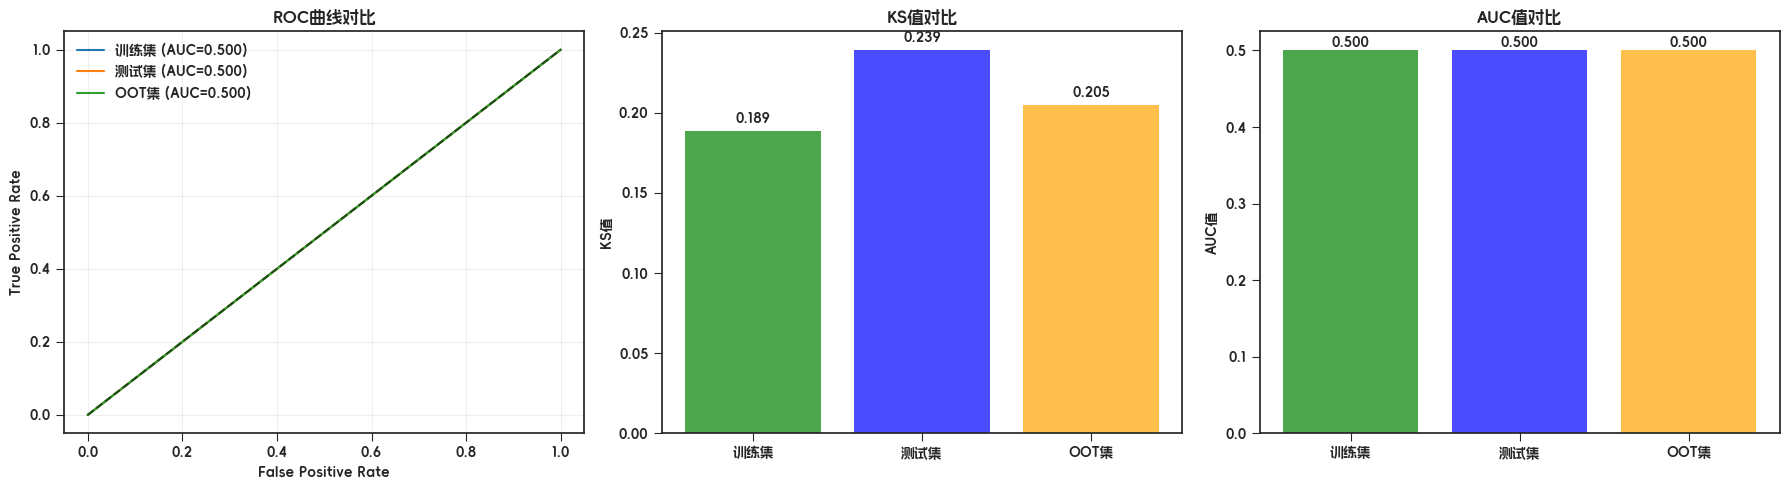

In [12]:
# 可视化评估结果
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KS曲线对比
from sklearn.metrics import roc_curve
for name, (y_true, y_prob) in [('训练集', (y_train, y_prob_train)), 
                                ('测试集', (y_test, y_prob_test)),
                                ('OOT集', (y_oot, y_prob_oot))]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={metrics.auc(y_true, y_prob):.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC曲线对比')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# KS值对比
datasets = ['训练集', '测试集', 'OOT集']
ks_values = [results[d]['KS'] for d in datasets]
axes[1].bar(datasets, ks_values, color=['green', 'blue', 'orange'], alpha=0.7)
axes[1].set_ylabel('KS值')
axes[1].set_title('KS值对比')
for i, v in enumerate(ks_values):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center')

# AUC对比
auc_values = [results[d]['AUC'] for d in datasets]
axes[2].bar(datasets, auc_values, color=['green', 'blue', 'orange'], alpha=0.7)
axes[2].set_ylabel('AUC值')
axes[2].set_title('AUC值对比')
for i, v in enumerate(auc_values):
    axes[2].text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

## 第六步: 特征重要性

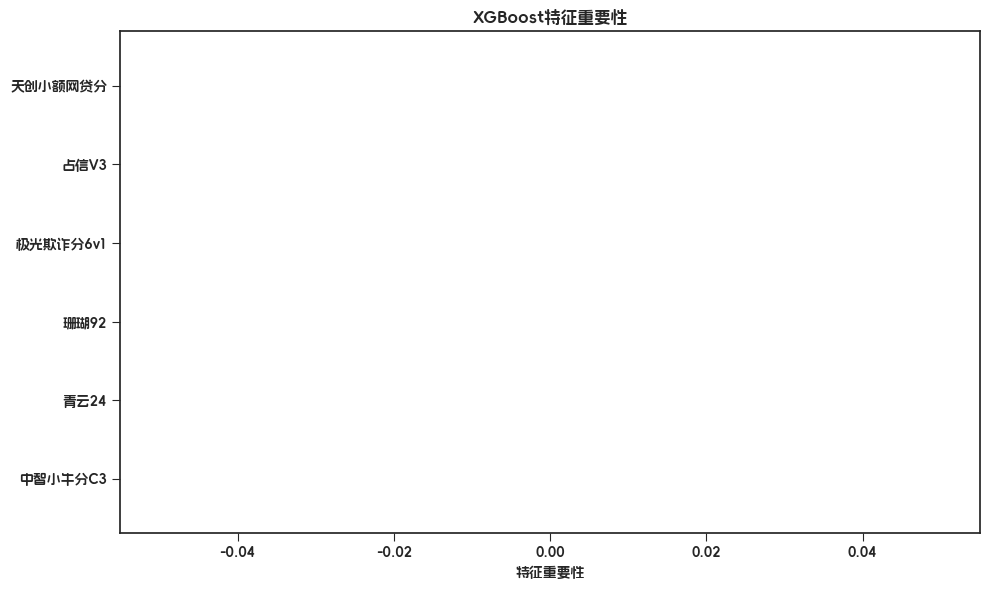

In [14]:
# 获取特征重要性
importance = xgb_model.get_feature_importances()
importance_df = pd.DataFrame(list(importance.items()), 
                             columns=['特征', '重要性'])
importance_df = importance_df.sort_values('重要性', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['特征'], importance_df['重要性'])
plt.xlabel('特征重要性')
plt.title('XGBoost特征重要性')
plt.tight_layout()
plt.show()

## 第七步: 生成模型报告

In [16]:
from hscredit.report import ExcelWriter

# 生成模型报告
report_file = 'model_report.xlsx'

with ExcelWriter(report_file) as writer:
    # Sheet 1: 报告封面
    cover_df = pd.DataFrame({
        '项目': ['模型名称', '模型版本', '生成时间', '样本总量', '特征数量', '算法类型'],
        '内容': ['贷后风险评分模型', 'v1.0', datetime.now().strftime('%Y-%m-%d %H:%M'), 
                len(X), len(selected_features), 'XGBoost']
    })
    writer.write_dataframe(cover_df, sheet_name='报告封面')
    
    # Sheet 2: 模型性能
    writer.write_dataframe(results_df.reset_index().rename(columns={'index': '数据集'}), 
                          sheet_name='模型性能')
    
    # Sheet 3: 特征重要性
    importance_sorted = importance_df.sort_values('重要性', ascending=False)
    writer.write_dataframe(importance_sorted, sheet_name='特征重要性')
    
    # Sheet 4: 特征IV值
    writer.write_dataframe(iv_df, sheet_name='特征IV值')
    
    # Sheet 5: 入模特征列表
    feature_info = pd.DataFrame({
        '特征名': selected_features,
        'IV值': [iv_df[iv_df['特征']==f]['IV'].values[0] for f in selected_features],
        '重要性': [importance.get(f, 0) for f in selected_features]
    })
    writer.write_dataframe(feature_info, sheet_name='入模特征列表')

print(f"模型报告已生成: {report_file}")
print("\n报告包含以下Sheet:")
print("  1. 报告封面")
print("  2. 模型性能")
print("  3. 特征重要性")
print("  4. 特征IV值")
print("  5. 入模特征列表")

AttributeError: 'ExcelWriter' object has no attribute 'write_dataframe'

## 总结

In [17]:
print("=" * 60)
print("建模工作流完成")
print("=" * 60)
print(f"\n最终模型性能:")
print(f"  训练集 KS: {results['训练集']['KS']:.4f}, AUC: {results['训练集']['AUC']:.4f}")
print(f"  测试集 KS: {results['测试集']['KS']:.4f}, AUC: {results['测试集']['AUC']:.4f}")
print(f"  OOT集  KS: {results['OOT集']['KS']:.4f}, AUC: {results['OOT集']['AUC']:.4f}")
print(f"\n入模特征 ({len(selected_features)}个):")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")
print("=" * 60)

建模工作流完成

最终模型性能:
  训练集 KS: 0.1885, AUC: 0.5000
  测试集 KS: 0.2389, AUC: 0.5000
  OOT集  KS: 0.2050, AUC: 0.5000

入模特征 (6个):
  1. 中智小牛分C3
  2. 青云24
  3. 珊瑚92
  4. 极光欺诈分6v1
  5. 占信V3
  6. 天创小额网贷分
